In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
dataset_path = "/content/drive/MyDrive/saudi-plates-dt.v1-ver1.yolov8"
print(os.listdir(dataset_path))

['README.roboflow.txt', 'README.dataset.txt', 'test', 'train', 'valid', 'data.yaml']


In [8]:
for root, dirs, files in os.walk(dataset_path):
    print("Folder:", root)
    print("Subfolders:", dirs[:5])
    print("Files:", files[:5])
    print("-" * 50)

Folder: /content/drive/MyDrive/saudi-plates-dt.v1-ver1.yolov8
Subfolders: ['test', 'train', 'valid']
Files: ['README.roboflow.txt', 'README.dataset.txt', 'data.yaml']
--------------------------------------------------
Folder: /content/drive/MyDrive/saudi-plates-dt.v1-ver1.yolov8/test
Subfolders: ['images', 'labels']
Files: []
--------------------------------------------------
Folder: /content/drive/MyDrive/saudi-plates-dt.v1-ver1.yolov8/test/images
Subfolders: []
Files: ['car_226_jpg.rf.40dfc71e6213ddcbae27f34552deba1e.jpg', 'car_280_jpg.rf.a47d01293883b3f2077dab130a8dcb8c.jpg', 'car_84_jpg.rf.bc01386db758e567c8e90a80b2d0b62d.jpg', 'car_55_jpg.rf.975df7b2e07a454b078bc01417096330.jpg', 'car_177_jpg.rf.fbf2c30a8c6b90a0a2afc0b1daf508af.jpg']
--------------------------------------------------
Folder: /content/drive/MyDrive/saudi-plates-dt.v1-ver1.yolov8/test/labels
Subfolders: []
Files: ['car_123_jpg.rf.24b2a5f7f50ee5f1efb8093a19eb5799.txt', 'ck7z3ym20m9670826pe80ydw6_jpeg.rf.70a02833eb2f6

In [9]:
yaml_path = "/content/drive/MyDrive/saudi-plates-dt.v1-ver1.yolov8/data.yaml"

with open(yaml_path, "r") as f:
    print(f.read())


train: /content/drive/MyDrive/saudi-plates-dt.v1-ver1.yolov8/train/images
val: /content/drive/MyDrive/saudi-plates-dt.v1-ver1.yolov8/valid/images
test: /content/drive/MyDrive/saudi-plates-dt.v1-ver1.yolov8/test/images

nc: 1
names: ['plate']



In [12]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [13]:
yaml_content = """
train: /content/drive/MyDrive/saudi-plates-dt.v1-ver1.yolov8/train/images
val: /content/drive/MyDrive/saudi-plates-dt.v1-ver1.yolov8/valid/images
test: /content/drive/MyDrive/saudi-plates-dt.v1-ver1.yolov8/test/images

nc: 1
names: ['plate']
"""

yaml_path = "/content/drive/MyDrive/saudi-plates-dt.v1-ver1.yolov8/data.yaml"

with open(yaml_path, "w") as f:
    f.write(yaml_content)

print("data.yaml updated successfully")

data.yaml updated successfully


In [14]:
model = YOLO("yolov8n.pt")

results = model.train(
    data="/content/drive/MyDrive/saudi-plates-dt.v1-ver1.yolov8/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    project="/content/drive/MyDrive/car_plate_runs",
    name="plate_detector_exp1"
)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/saudi-plates-dt.v1-ver1.yolov8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=plate_detector_exp12, nbs=64, nms=False, opset=None, optimize=False, optimizer=a

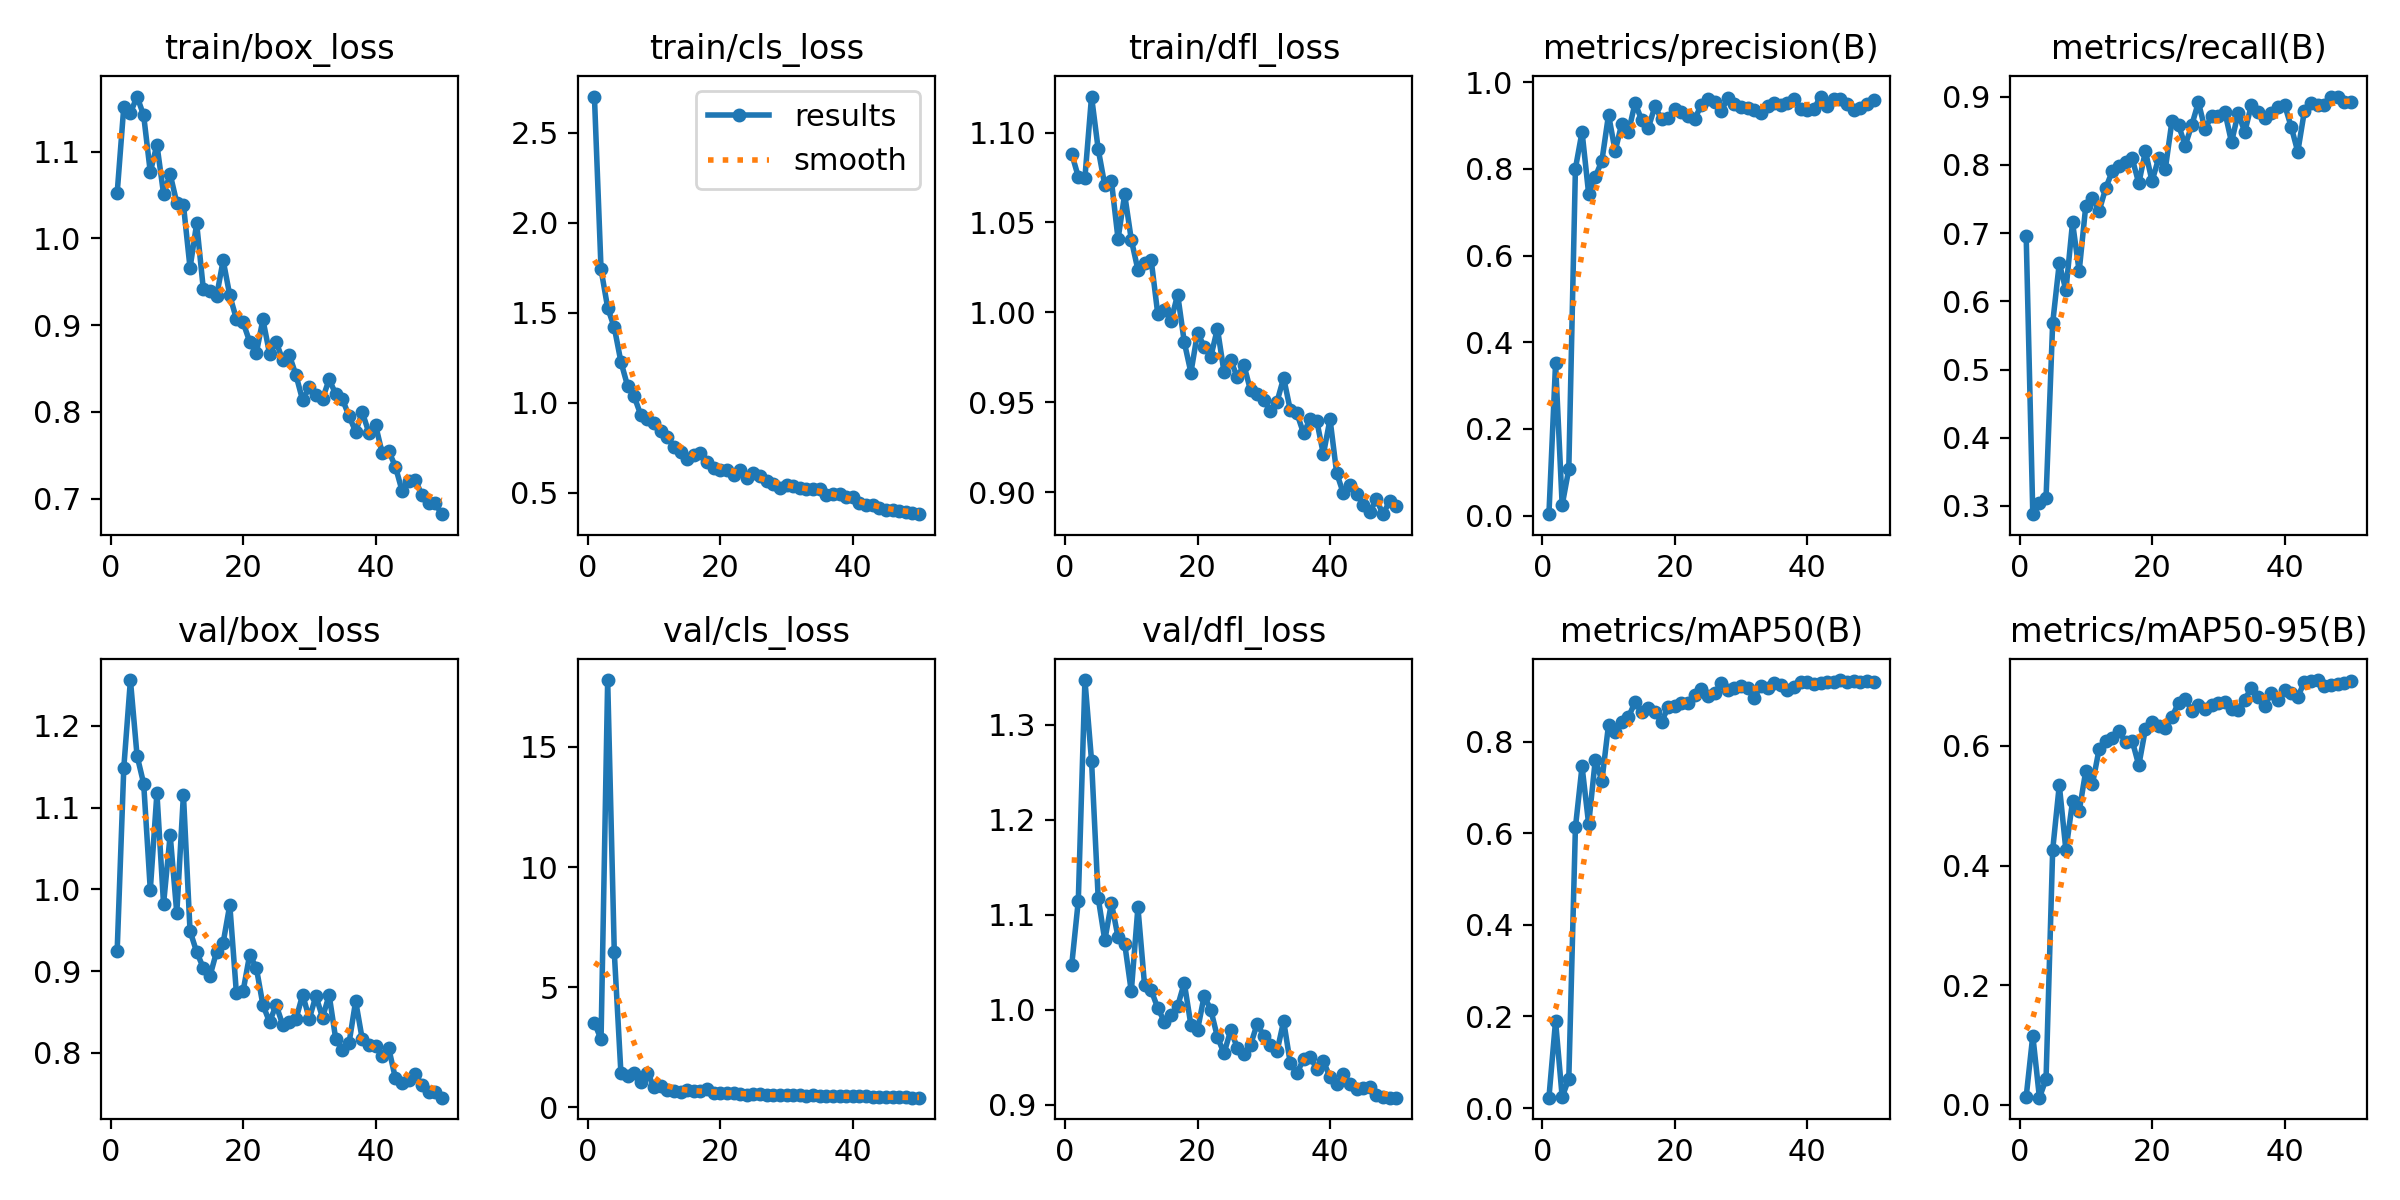

In [15]:
from IPython.display import Image, display

display(Image(filename="/content/drive/MyDrive/car_plate_runs/plate_detector_exp1/results.png"))

In [16]:
trained_model = YOLO("/content/drive/MyDrive/car_plate_runs/plate_detector_exp1/weights/best.pt")

results = trained_model.predict(
    source="/content/drive/MyDrive/saudi-plates-dt.v1-ver1.yolov8/test/images",
    save=True,
    conf=0.25
)


image 1/86 /content/drive/MyDrive/saudi-plates-dt.v1-ver1.yolov8/test/images/Screenshot-2024-09-14-at-09-50-24_png.rf.b203ad82f90b85b90a1d01586baa8d89.jpg: 640x640 5 plates, 9.7ms
image 2/86 /content/drive/MyDrive/saudi-plates-dt.v1-ver1.yolov8/test/images/Screenshot-2024-09-14-at-09-54-02_png.rf.9804827aff9337603eb68cdb06499523.jpg: 640x640 2 plates, 10.7ms
image 3/86 /content/drive/MyDrive/saudi-plates-dt.v1-ver1.yolov8/test/images/Screenshot-2024-09-14-at-09-55-02_png.rf.5e857e6da8b453600f6289be3a06dcd5.jpg: 640x640 2 plates, 7.3ms
image 4/86 /content/drive/MyDrive/saudi-plates-dt.v1-ver1.yolov8/test/images/Screenshot-2024-09-14-at-09-58-23_png.rf.5f85e4d502dd47f32aca529dbc75bf2b.jpg: 640x640 1 plate, 7.2ms
image 5/86 /content/drive/MyDrive/saudi-plates-dt.v1-ver1.yolov8/test/images/Screenshot-2024-09-14-at-10-00-03_png.rf.28dd23ae7d2e7096eb98a762df2a2f7c.jpg: 640x640 4 plates, 7.3ms
image 6/86 /content/drive/MyDrive/saudi-plates-dt.v1-ver1.yolov8/test/images/car_103_jpg.rf.7c9af30

In [17]:
from ultralytics import YOLO

In [18]:
yaml_content = """
train: /content/drive/MyDrive/saudi-plates-dt.v1-ver1.yolov8/train/images
val: /content/drive/MyDrive/saudi-plates-dt.v1-ver1.yolov8/valid/images
test: /content/drive/MyDrive/saudi-plates-dt.v1-ver1.yolov8/test/images

nc: 1
names: ['plate']
"""

yaml_path = "/content/drive/MyDrive/saudi-plates-dt.v1-ver1.yolov8/data.yaml"

with open(yaml_path, "w") as f:
    f.write(yaml_content)

print("data.yaml updated successfully")

data.yaml updated successfully


In [19]:
import os

weights_path = "/content/drive/MyDrive/car_plate_runs/plate_detector_exp1/weights"

print("Folder exists:", os.path.exists(weights_path))

if os.path.exists(weights_path):
    print(os.listdir(weights_path))

Folder exists: True
['best.pt', 'last.pt']


In [20]:
import os

pred_folder = "/content/runs/detect/predict"
print(os.listdir(pred_folder)[:5])

['car_312_jpg.rf.0fc865cd86fe960c7206ac61c8c48c94.jpg', 'car_52_jpg.rf.079aa979ece359503f9aa6cff435e2e8.jpg', 'car_47_jpg.rf.af1941897c3758c6712a71b9b82a11b1.jpg', 'car_167_jpg.rf.d73d5c0ae15083249548966dfae10233.jpg', 'car_226_jpg.rf.40dfc71e6213ddcbae27f34552deba1e.jpg']


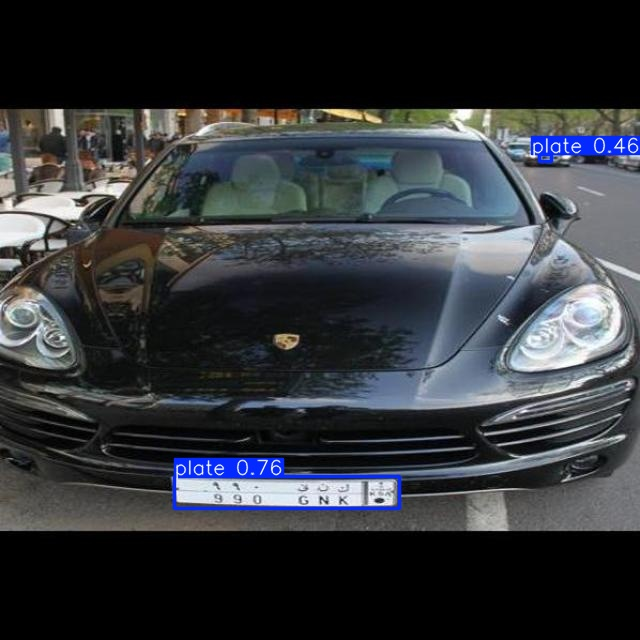

In [21]:
from IPython.display import Image, display

files = os.listdir("/content/runs/detect/predict")

display(Image(filename="/content/runs/detect/predict/" + files[0]))

In [22]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/car_plate_runs/plate_detector_exp1/weights/best.pt")

results = model.predict(
    source="/content/drive/MyDrive/my_test_images",
    save=True,
    conf=0.25
)


image 1/8 /content/drive/MyDrive/my_test_images/WhatsApp Image 2026-04-01 at 12.34.36 AM.jpeg: 512x640 1 plate, 66.5ms
image 2/8 /content/drive/MyDrive/my_test_images/WhatsApp Image 2026-04-01 at 9.55.47 AM.jpeg: 640x640 1 plate, 11.9ms
image 3/8 /content/drive/MyDrive/my_test_images/WhatsApp Image 2026-04-01 at 9.55.48 AM (1).jpeg: 640x640 1 plate, 7.2ms
image 4/8 /content/drive/MyDrive/my_test_images/WhatsApp Image 2026-04-01 at 9.55.48 AM (2).jpeg: 640x320 (no detections), 40.5ms
image 5/8 /content/drive/MyDrive/my_test_images/WhatsApp Image 2026-04-01 at 9.55.48 AM (3).jpeg: 640x320 1 plate, 6.4ms
image 6/8 /content/drive/MyDrive/my_test_images/WhatsApp Image 2026-04-01 at 9.55.48 AM (4).jpeg: 640x512 1 plate, 41.0ms
image 7/8 /content/drive/MyDrive/my_test_images/WhatsApp Image 2026-04-01 at 9.55.48 AM.jpeg: 640x608 1 plate, 40.2ms
image 8/8 /content/drive/MyDrive/my_test_images/WhatsApp Image 2026-04-01 at 9.55.51 AM.jpeg: 416x640 2 plates, 41.4ms
Speed: 2.7ms preprocess, 31.9ms

In [23]:
import os

pred_folder = "/content/runs/detect/predict"
print(os.listdir(pred_folder))

['car_312_jpg.rf.0fc865cd86fe960c7206ac61c8c48c94.jpg', 'car_52_jpg.rf.079aa979ece359503f9aa6cff435e2e8.jpg', 'car_47_jpg.rf.af1941897c3758c6712a71b9b82a11b1.jpg', 'car_167_jpg.rf.d73d5c0ae15083249548966dfae10233.jpg', 'car_226_jpg.rf.40dfc71e6213ddcbae27f34552deba1e.jpg', 'car_106_jpg.rf.8fe58a62d75387100f73b10a89aa1046.jpg', 'ckifkl2y7008z246a7tptseu1_jpeg.rf.6f3fa8071f940d54ae0a96d1317860cb.jpg', 'car_234_jpg.rf.2e6d0c372ec58bb98d5b196da831a626.jpg', 'car_266_jpg.rf.30e0d5be8a9a0bce731fb9fb47632554.jpg', 'car_267_jpg.rf.780e8ab84ffe7434388d4ecc5eade168.jpg', 'car_212_jpg.rf.b4a92eba215ba0f4106e97e0166bdef5.jpg', 'ckbf6rhcl9g8g0766v3420lfm_jpeg.rf.32b57e605b3a6ebb566f3e36d7642bab.jpg', 'ckbdrk4gkz59s0766d78ijd7u_jpeg.rf.0933de5d7c5b43de0212a3bc322f8423.jpg', 'car_97_jpg.rf.4290aa26392ece7b130008d01034f268.jpg', 'ckbf8pfqsdkvu0720k0wtvtsd_jpeg.rf.57c405acdfb89b564803b2e7e368cf4d.jpg', 'car_71_jpg.rf.cf5caaa77dc76649cc4bc650b7d2576f.jpg', 'car_313_jpg.rf.60b83a2eea9ba9223edd2ffaec3048e

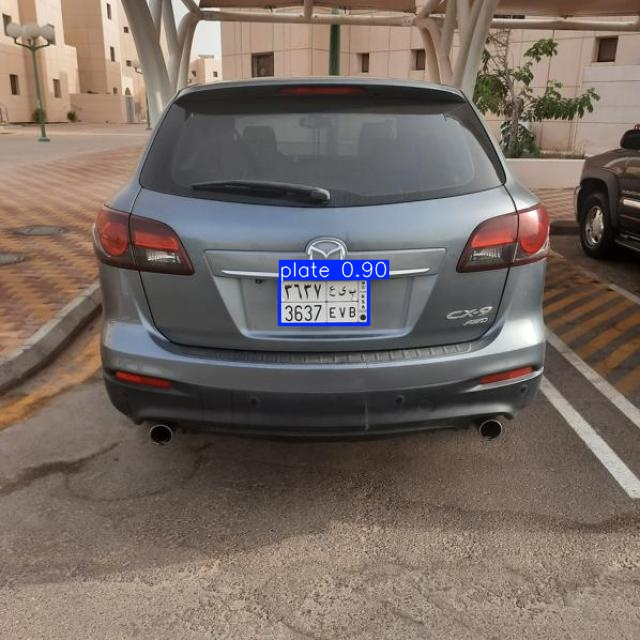

In [24]:
from IPython.display import Image, display
import os

pred_folder = "/content/runs/detect/predict"
files = os.listdir(pred_folder)

display(Image(filename=os.path.join(pred_folder, files[85])))

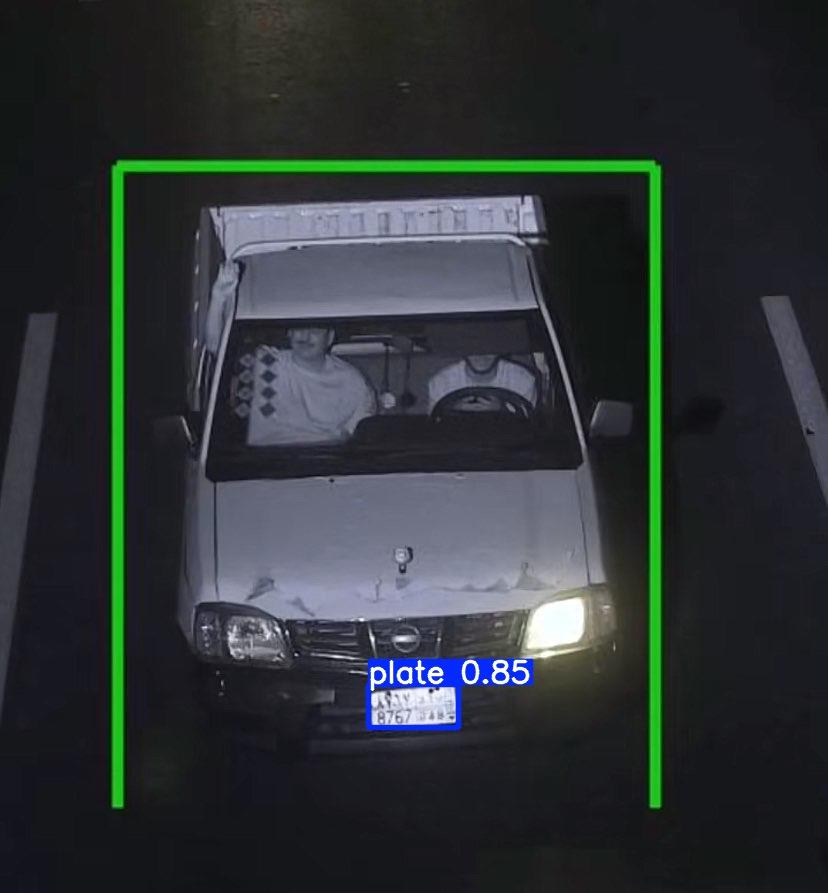

In [45]:
from IPython.display import Image, display

display(Image(filename="/content/runs/detect/predict2/WhatsApp Image 2026-04-01 at 9.55.48 AM.jpg"))